# EDA

Цель: понять структуру данных, качество файла событий и первые различия между ботами и людьми.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')

## 1. Загрузка данных

In [2]:
DATES = ['cookie_created_at', 'window_start_ts', 'window_end_ts']
train = pd.read_csv('data/train.csv', parse_dates=DATES)
test = pd.read_csv('data/test.csv', parse_dates=DATES)
events = pd.read_csv('data/events.csv.gz', parse_dates=['event_ts'])

print('train :', train.shape)
print('test  :', test.shape)
print('events:', events.shape)

train : (11091, 5)
test  : (4909, 4)
events: (328905, 14)


In [3]:
train.head()

,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target
0,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07,0
1,ck_7e4de46eeab82974,2025-09-23 10:10:24,2026-04-06,2026-04-07,0
2,ck_9320229ef6304522,2026-03-04 00:08:02,2026-04-06,2026-04-07,0
3,ck_30ccd25bc1714ed9,2026-04-05 10:52:40,2026-04-06,2026-04-07,0
4,ck_a77c5f05948cdeef,2026-01-01 03:54:35,2026-04-06,2026-04-07,0


In [4]:
events.head()

,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
0,ck_5efbea1befdefe1b,2026-04-26 09:11:24,200,item_view,desktop,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1027450.0,elektronika,kaliningrad,pro,NaN,NaN,NaN,NaN
1,ck_c4ca1434f3778f1d,2026-04-20 14:04:31,100,search_results_view,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,telefony,habarovsk,NaN,iphone 13 128,4.0,NaN,NaN
2,ck_d274382b19488771,2026-04-13 12:02:56,200,item_view,WEB,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1048743.0,kvartiry_prodazha,kirov,private,NaN,NaN,675.0,276.0
3,ck_fbbed2ff14944ce9,2026-04-08 06:12:14,100,search_results_view,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,bytovaya_tehnika,novosibirsk,NaN,пылесос dyson,2.0,NaN,NaN
4,ck_56cc15c7c634cb9f,2026-04-12 17:16:05,100,search_results_view,WEB,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,odezhda,sankt-peterburg,NaN,костюм мужской,2.0,NaN,NaN


## 2. train / test

In [5]:
print('cookie_id уникальны в train:', train.cookie_id.is_unique)
print('cookie_id уникальны в test :', test.cookie_id.is_unique)
print('пересечение train ∩ test   :', len(set(train.cookie_id) & set(test.cookie_id)))
print()
print('доля ботов в train:', train.target.mean().round(4), f'({train.target.sum()} из {len(train)})')

cookie_id уникальны в train: True
cookie_id уникальны в test : True
пересечение train ∩ test   : 0

доля ботов в train: 0.0811 (899 из 11091)


In [6]:
# временные диапазоны окон
for name, df in [('train', train), ('test', test)]:
    print(f"{name:5s} window_start: {df.window_start_ts.min()} → {df.window_start_ts.max()}")
    print(f"{name:5s} длины окон  : {(df.window_end_ts - df.window_start_ts).value_counts().to_dict()}")

train window_start: 2026-04-06 00:00:00 → 2026-04-19 00:00:00
train длины окон  : {Timedelta('1 days 00:00:00'): 11091}
test  window_start: 2026-04-20 00:00:00 → 2026-04-26 00:00:00
test  длины окон  : {Timedelta('1 days 00:00:00'): 4909}


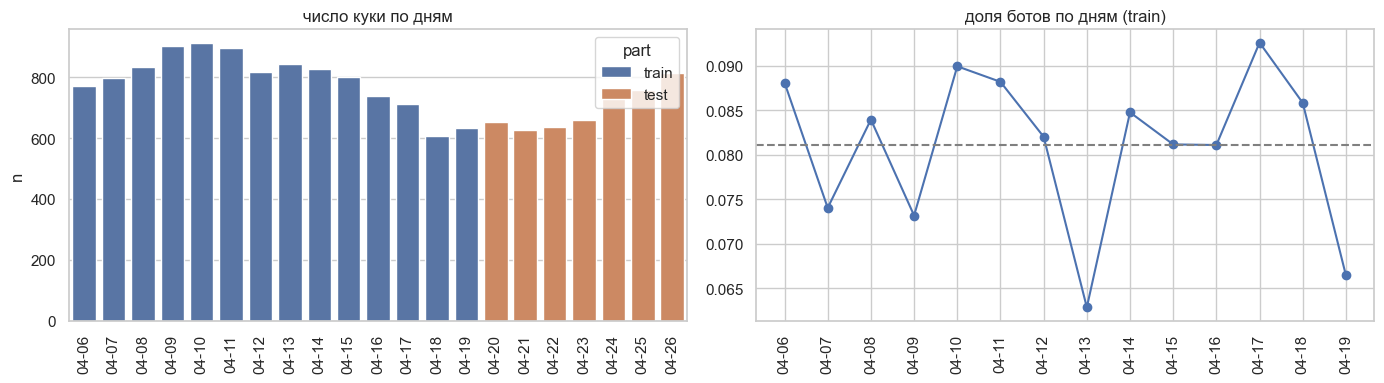

In [7]:
# число куки и доля ботов по дням
by_day = (pd.concat([train.assign(part='train'), test.assign(part='test')])
            .groupby([pd.Grouper(key='window_start_ts', freq='D'), 'part'])
            .agg(n=('cookie_id', 'size'), bot_rate=('target', 'mean'))
            .reset_index())

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=by_day, x=by_day.window_start_ts.dt.strftime('%m-%d'), y='n', hue='part', ax=ax[0])
ax[0].set_title('число куки по дням'); ax[0].tick_params(axis='x', rotation=90); ax[0].set_xlabel('')
tr_day = by_day[by_day.part == 'train']
ax[1].plot(tr_day.window_start_ts.dt.strftime('%m-%d'), tr_day.bot_rate, marker='o')
ax[1].axhline(train.target.mean(), ls='--', c='gray')
ax[1].set_title('доля ботов по дням (train)'); ax[1].tick_params(axis='x', rotation=90)
plt.tight_layout(); plt.show()

count    4909.00
mean       71.65
std        68.00
min         0.02
25%        12.14
50%        58.63
75%       107.64
max       465.29
Name: cookie_age_days, dtype: float64


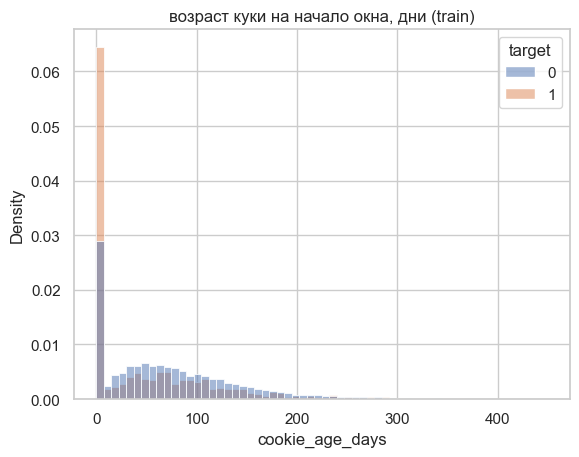

In [8]:
# возраст куки на момент начала окна
for df in (train, test):
    df['cookie_age_days'] = (df.window_start_ts - df.cookie_created_at).dt.total_seconds() / 86400

print(test.cookie_age_days.describe().round(2))
sns.histplot(data=train, x='cookie_age_days', hue='target', bins=60, stat='density', common_norm=False)
plt.title('возраст куки на начало окна, дни (train)'); plt.show()

## 3. Качество файла events

Как в quickstart проверяем порядок строк, дубликаты, пропуски.

In [9]:
events.dtypes

cookie_id                object
event_ts         datetime64[ns]
eid                       int64
event_name               object
platform                 object
user_agent               object
item_id                 float64
item_category            object
item_location            object
seller_type              object
search_query             object
search_page             float64
pointer_x               float64
pointer_y               float64
dtype: object

In [10]:
print('пропуски по колонкам:')
print(events.isna().mean().round(3).sort_values(ascending=False))

пропуски по колонкам:
search_query     0.695
search_page      0.695
pointer_x        0.670
pointer_y        0.670
seller_type      0.407
item_id          0.348
item_category    0.100
item_location    0.072
cookie_id        0.000
event_ts         0.000
eid              0.000
event_name       0.000
platform         0.000
user_agent       0.000
dtype: float64


In [11]:
# порядок строк
print('отсортирован по event_ts глобально       :', events.event_ts.is_monotonic_increasing)
s = events.groupby('cookie_id', sort=False).event_ts.apply(lambda x: x.is_monotonic_increasing)
print('доля куки с упорядоченными событиями     :', s.mean().round(3))

отсортирован по event_ts глобально       : False
доля куки с упорядоченными событиями     : 0.035


In [15]:
# дубликаты
print('полные дубликаты строк                 :', events.duplicated().sum())
print('дубли по cookie_id, event_ts, eid      :', events.duplicated(['cookie_id', 'event_ts', 'eid']).sum())

полные дубликаты строк                 : 4863
дубли по cookie_id, event_ts, eid      : 5270


In [17]:
# однозначное ли соответствие у eid и event_name
m = events.groupby(['eid', 'event_name'], dropna=False).size().reset_index(name='n')
print('eid с несколькими event_name :', (m.groupby('eid').event_name.nunique() > 1).sum())
print('event_name с несколькими eid :', (m.groupby('event_name').eid.nunique() > 1).sum())
m.sort_values('eid')

eid с несколькими event_name : 0
event_name с несколькими eid : 0


,eid,event_name,n
0,100,search_results_view,100402
1,200,item_view,120817
2,210,photo_swipe,36517
3,220,seller_page_view,17403
4,300,contact_phone_show,11316
5,301,contact_chat_open,6125
6,303,contact_message_sent,3081
7,400,favorite_add,19049
8,500,login,6267
9,900,captcha_shown,7928


In [21]:
# как записан platform  — смотрим на различные вариации
events.platform.value_counts(dropna=False)

platform
desktop    46866
WEB        46476
Web        46365
web        45951
ANDROID    42462
Android    42254
android    42159
iphone      4103
IOS         4100
iOS         4091
ios         4078
Name: count, dtype: int64

## 4. События относительно окон

Окно полуоткрытое: `window_start_ts <= event_ts < window_end_ts`.

In [22]:
meta = pd.concat([train.assign(part='train'), test.assign(part='test', target=np.nan)], ignore_index=True)

ev = events.merge(meta[['cookie_id', 'window_start_ts', 'window_end_ts', 'part', 'target']],
                  on='cookie_id', how='left')
print('события без куки в train/test:', ev.part.isna().sum())

ev['pos'] = np.select(
    [ev.event_ts < ev.window_start_ts, ev.event_ts >= ev.window_end_ts],
    ['before', 'after'], 'inside')
print(ev.groupby('part').pos.value_counts(normalize=True).round(3))

события без куки в train/test: 0
part   pos   
test   inside    1.00
train  inside    0.83
       after     0.17
Name: proportion, dtype: float64


In [23]:
ev_in = ev[ev.pos == 'inside'].copy()

n_ev = ev_in.groupby('cookie_id').size()
meta['n_events'] = meta.cookie_id.map(n_ev).fillna(0).astype(int)
print('куки без событий в окне:')
print(meta.assign(empty=meta.n_events == 0).groupby('part').empty.agg(['sum', 'mean']).round(3))

куки без событий в окне:
       sum  mean
part            
test     0   0.0
train    0   0.0


## 5. Первые различия бот/человек 

In [24]:
ev_tr = ev_in[ev_in.part == 'train']

# доля каждого типа события у ботов и людей
en = pd.crosstab(ev_tr.event_name, ev_tr.target, normalize='columns').round(3)
en.columns = ['human', 'bot']
en['ratio_bot/human'] = (en.bot / en.human).round(2)
en.sort_values('ratio_bot/human', ascending=False)

,human,bot,ratio_bot/human
event_name,,,
item_view,0.365,0.436,1.19
search_results_view,0.305,0.352,1.15
seller_page_view,0.053,0.059,1.11
contact_message_sent,0.010,0.008,0.80
contact_chat_open,0.020,0.014,0.70
contact_phone_show,0.037,0.026,0.70
photo_swipe,0.123,0.070,0.57
favorite_add,0.066,0.027,0.41
login,0.021,0.008,0.38


In [26]:
# то же самое для platform
pl = pd.crosstab(ev_tr.platform.fillna('NA'), ev_tr.target, normalize='columns').round(3)
pl.columns = ['human', 'bot']
pl

,human,bot
platform,,
ANDROID,0.140,0.080
Android,0.139,0.077
IOS,0.015,0.005
WEB,0.130,0.188
Web,0.132,0.182
android,0.139,0.077
desktop,0.133,0.189
iOS,0.014,0.006
ios,0.014,0.005


          count  mean   std  min   25%   50%   75%    max
target                                                   
0.0     10192.0  16.9  16.2  1.0   6.0  12.0  22.0  140.0
1.0       899.0  29.5  27.5  1.0  11.0  20.0  38.0  169.0


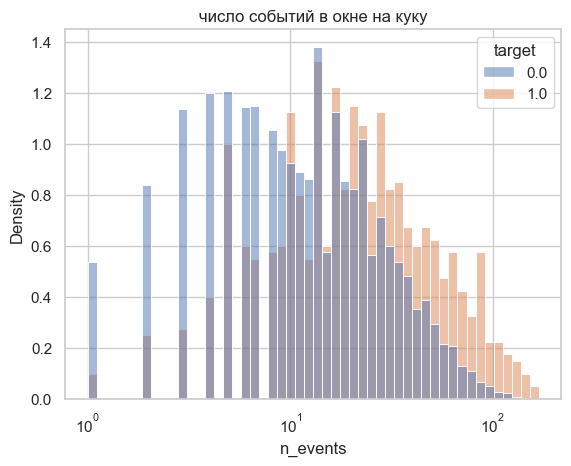

In [27]:
# число событий на куку
tr_meta = meta[meta.part == 'train']
print(tr_meta.groupby('target').n_events.describe().round(1))
sns.histplot(data=tr_meta, x='n_events', hue='target', log_scale=(True, False),
             bins=50, stat='density', common_norm=False)
plt.title('число событий в окне на куку'); plt.show()

## 6. События после окна и дубликаты по классам на train

In [28]:
ev_trall = ev[ev.part == 'train']

print('доля событий после окна:')
print(ev_trall.groupby('target').pos.apply(lambda s: (s == 'after').mean()).round(3))
print()
print('доля куки, у которых есть события после окна:')
print(ev_trall.groupby('cookie_id').agg(y=('target', 'first'), has_after=('pos', lambda s: (s == 'after').any()))
      .groupby('y').has_after.mean().round(3))

доля событий после окна:
target
0.0    0.110
1.0    0.425
Name: pos, dtype: float64

доля куки, у которых есть события после окна:
y
0.0    0.45
1.0    0.77
Name: has_after, dtype: float64


In [30]:
# что лежит после окна
after = pd.crosstab(ev_trall[ev_trall.pos == 'after'].event_name,
                    ev_trall[ev_trall.pos == 'after'].target, normalize='columns').round(3)
after.columns = ['human', 'bot']
after.sort_values('bot', ascending=False)

,human,bot
event_name,,
captcha_shown,0.045,0.356
item_view,0.355,0.266
search_results_view,0.296,0.221
photo_swipe,0.115,0.050
seller_page_view,0.052,0.039
favorite_add,0.063,0.022
contact_phone_show,0.029,0.021
contact_chat_open,0.015,0.013
login,0.022,0.007


In [31]:
# дубликаты: какой-то артефакт логирования или поведение?
ev_trall = ev_trall.assign(dup=ev_trall.duplicated(subset=events.columns))
print('доля полных дублей по классам:')
print(ev_trall.groupby('target').dup.mean().round(4))

доля полных дублей по классам:
target
0.0    0.0148
1.0    0.0142
Name: dup, dtype: float64


## 7. Возраст куки

In [33]:
train['age_h'] = (train.window_start_ts - train.cookie_created_at).dt.total_seconds() / 3600
bins = [0, 1, 6, 24, 72, 168, 720, np.inf]
age_tab = train.groupby(pd.cut(train.age_h, bins), observed=False).target.agg(bot_rate='mean', n='size')
age_tab['bot_rate'] = age_tab.bot_rate.round(3)
age_tab

,bot_rate,n
age_h,,
"(0.0, 1.0]",0.231,13
"(1.0, 6.0]",0.184,239
"(6.0, 24.0]",0.178,1044
"(24.0, 72.0]",0.157,1080
"(72.0, 168.0]",0.117,256
"(168.0, 720.0]",0.050,939
"(720.0, inf]",0.056,7520


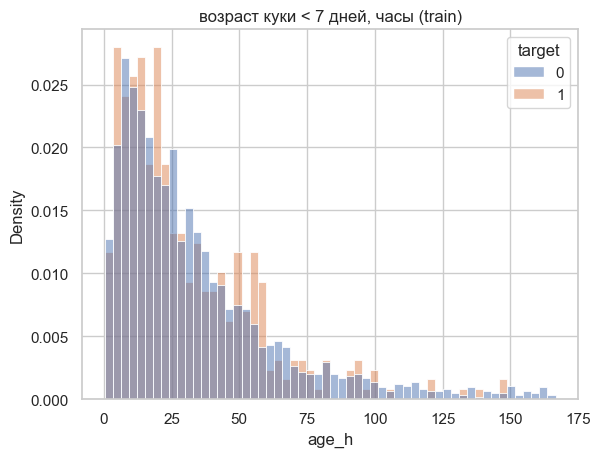

In [34]:
fresh = train[train.age_h < 168]
sns.histplot(data=fresh, x='age_h', hue='target', bins=56, stat='density', common_norm=False)
plt.title('возраст куки < 7 дней, часы (train)'); plt.show()

In [35]:
# сколько времени прошло от создания куки до её первого события в окне
first_ev = ev_in.groupby('cookie_id').event_ts.min()
train['gap_first_h'] = (train.cookie_id.map(first_ev) - train.cookie_created_at).dt.total_seconds() / 3600
print(train.groupby('target').gap_first_h.describe().round(1))

          count    mean     std  min    25%     50%     75%      max
target                                                              
0       10192.0  1786.8  1607.4  1.8  466.9  1494.8  2665.5  10787.9
1         899.0  1181.1  1507.4  3.7   36.2   459.9  2016.2   8705.0


## 8. Клиент (User-Agent)

In [36]:
PLATFORM_MAP = {'web': 'web', 'desktop': 'web', 'android': 'android', 'ios': 'ios', 'iphone': 'ios'}
ev_in['plat'] = ev_in.platform.str.lower().map(PLATFORM_MAP)
print(ev_in.plat.value_counts(dropna=False))

def ua_family(ua: str) -> str:
    if 'Headless' in ua: return 'headless'
    if ua.startswith('Avito/') and 'Android' in ua: return 'app_android'
    if ua.startswith('Avito/') and 'iPhone' in ua: return 'app_ios'
    if 'YaBrowser' in ua: return 'yabrowser'
    if 'Firefox' in ua: return 'firefox'
    if 'Chrome' in ua and 'Android' in ua: return 'chrome_android'
    if 'Chrome' in ua: return 'chrome_desktop'
    if 'iPhone' in ua and 'Safari' in ua: return 'safari_ios'
    return 'lib: ' + ua.split('/')[0]      # curl, python-requests и т.п.

ev_in['ua_fam'] = ev_in.user_agent.map(ua_family)
pd.crosstab(ev_in.ua_fam, ev_in.plat)

plat
web        161262
android    112256
ios         14608
Name: count, dtype: int64


plat,android,ios,web
ua_fam,,,
app_android,42185,0,0
app_ios,0,9939,0
chrome_android,70071,0,0
chrome_desktop,0,0,73221
firefox,0,0,38073
headless,0,0,10435
lib: Go-http-client,0,0,976
lib: Scrapy,0,0,998
lib: curl,0,0,982


In [38]:
# Доля ботов по семействам клиентов (браузер, приложение, скрипт) и их доля в train и test
ck = (ev_in.sort_values('event_ts')
            .groupby('cookie_id')
            .agg(part=('part', 'first'), target=('target', 'first'),
                 ua_fam=('ua_fam', 'first'), ua_n=('user_agent', 'nunique'), plat=('plat', 'first')))

fam = ck[ck.part == 'train'].groupby('ua_fam').target.agg(bot_rate='mean', n='size').round(3)
fam['share_train'] = ck[ck.part == 'train'].ua_fam.value_counts(normalize=True).round(3)
fam['share_test'] = ck[ck.part == 'test'].ua_fam.value_counts(normalize=True).round(3)
fam.sort_values('bot_rate', ascending=False)

,bot_rate,n,share_train,share_test
ua_fam,,,,
lib: node-fetch,0.273,33,0.003,0.002
headless,0.262,286,0.026,0.028
lib: Scrapy,0.257,35,0.003,0.003
lib: curl,0.250,32,0.003,0.002
lib: python-urllib3,0.194,31,0.003,0.003
lib: python-requests,0.185,27,0.002,0.003
lib: Go-http-client,0.167,42,0.004,0.002
app_android,0.103,1754,0.158,0.146
chrome_desktop,0.088,2787,0.251,0.255


In [39]:
print('число разных UA на куку:')
print(ck[ck.part == 'train'].groupby('ua_n').target.agg(bot_rate='mean', n='size').round(3))
print()
ua_tr, ua_te = set(ev_in[ev_in.part == 'train'].user_agent), set(ev_in[ev_in.part == 'test'].user_agent)
print(f'уникальных UA: train {len(ua_tr)}, test {len(ua_te)}, только в test {len(ua_te - ua_tr)}')

число разных UA на куку:
      bot_rate      n
ua_n                 
1        0.082  10295
2        0.009    107
3        0.073    689

уникальных UA: train 148, test 148, только в test 0


In [41]:
# Доля ботов по конкретным строкам UA (только встречающиеся у 30+ куки + 20 с наибольшим количеством ботов)
ua_ck = ev_in[ev_in.part == 'train'].groupby('cookie_id').agg(ua=('user_agent', 'first'), target=('target', 'first'))
ua_tab = ua_ck.groupby('ua').target.agg(bot_rate='mean', n='size')
ua_tab[ua_tab.n >= 30].sort_values('bot_rate', ascending=False).round(3).head(20)

,bot_rate,n
ua,,
"Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) HeadlessChrome/118.0.0.0 Safari/537.36",0.329,79
Avito/118.0 (Android 11; M2101K6G) okhttp/4.11.0,0.283,53
node-fetch/3.3.2,0.273,33
Scrapy/2.11.0 (+https://scrapy.org),0.257,35
curl/8.1.2,0.250,32
Avito/122.0 (Android 13; SM-A515F) okhttp/4.11.0,0.246,65
"Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) HeadlessChrome/124.0.0.0 Safari/537.36",0.241,58
"Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) HeadlessChrome/120.0.0.0 Safari/537.36",0.239,67
"Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) HeadlessChrome/114.0.0.0 Safari/537.36",0.232,82


## 9. Интервалы между событиями

In [45]:
# чистим события, считаем интервал до следующего события куки и сравниваем интервалы ботов и людей
ev_clean = (ev_in.drop_duplicates(subset=events.columns)
                 .sort_values(['cookie_id', 'event_ts'])
                 .reset_index(drop=True))
ev_clean['dt'] = ev_clean.groupby('cookie_id').event_ts.diff().dt.total_seconds()
print(len(ev_in), '→', len(ev_clean))

tr_clean = ev_clean[ev_clean.part == 'train']
print(tr_clean.groupby('target').dt.describe().round(1))
print()
print('доля нулевых интервалов - dt == 0:')
print(tr_clean.groupby('target').dt.apply(lambda x: (x == 0).mean()).round(4))

288126 → 283833
           count   mean     std  min   25%   50%    75%     max
target                                                         
0.0     159187.0  744.1  1904.8  0.0  20.0  47.0  120.0  9760.0
1.0      25206.0  430.9  1489.7  0.0   7.0  14.0   35.0  9608.0

доля нулевых интервалов - dt == 0:
target
0.0    0.0059
1.0    0.0013
Name: dt, dtype: float64


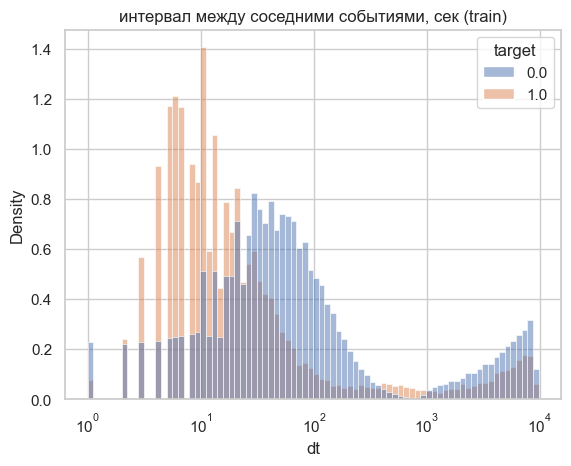

In [46]:
# распределение интервалов, лог-шкала
d = tr_clean[tr_clean.dt > 0]
sns.histplot(data=d, x='dt', hue='target', log_scale=True, bins=80, stat='density', common_norm=False)
plt.title('интервал между соседними событиями, сек (train)'); plt.show()

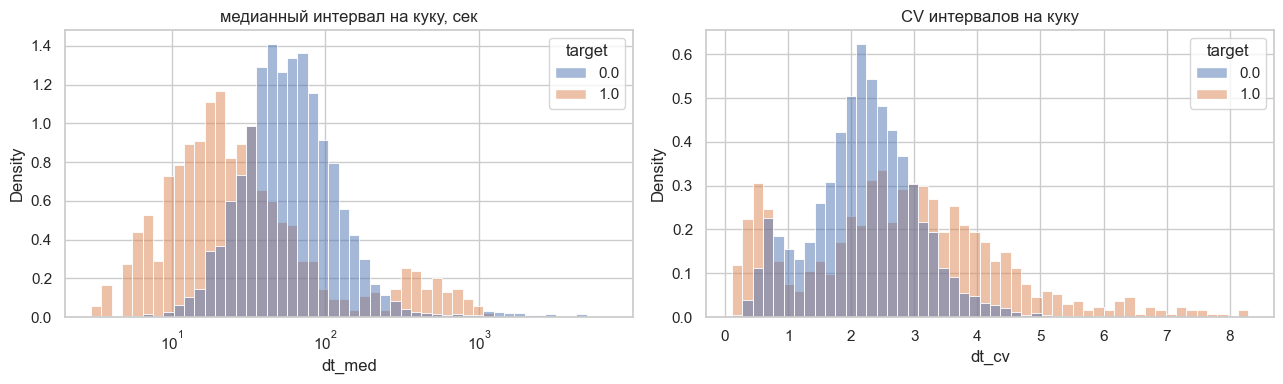

In [48]:
# Медианный интервал и коэффициент вариации интервалов для каждой куки с 5+ интервалами
g = tr_clean.groupby('cookie_id').agg(target=('target', 'first'), n_dt=('dt', 'count'),
                                      dt_med=('dt', 'median'), dt_mean=('dt', 'mean'),
                                      dt_std=('dt', 'std'), dt_min=('dt', 'min'))
g['dt_cv'] = g.dt_std / g.dt_mean
g5 = g[g.n_dt >= 5]

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(data=g5, x='dt_med', hue='target', log_scale=True, bins=50, stat='density', common_norm=False, ax=ax[0])
ax[0].set_title('медианный интервал на куку, сек')
sns.histplot(data=g5, x='dt_cv', hue='target', bins=50, stat='density', common_norm=False, ax=ax[1])
ax[1].set_title('CV интервалов на куку')
plt.tight_layout(); plt.show()

**Медианный интервал** — медианная пауза между действиями куки.
Беру медиану, а не среднее, чтобы редкие длинные перерывы между сессиями не искажали результат.

**Коэффициент вариации (CV)** — насколько неравномерен ритм действий куки. Это разброс интервалов, делённый на их среднее:

$$
\text{CV} = \frac{\sigma_{\Delta t}}{\mu_{\Delta t}}
$$

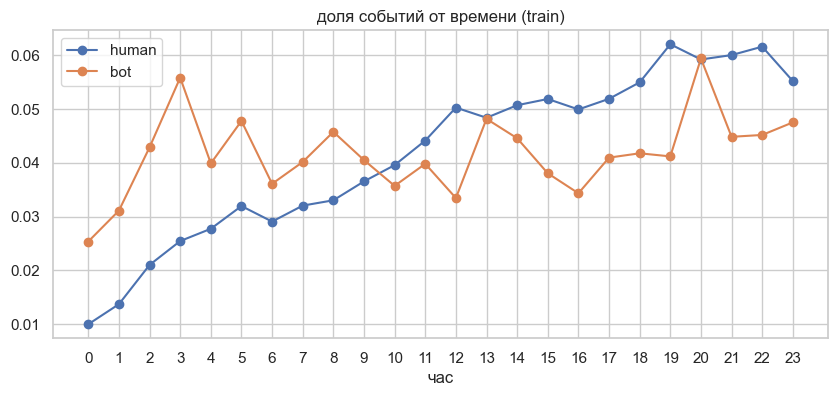

In [50]:
# активность в течении суток
hours = pd.crosstab(tr_clean.event_ts.dt.hour, tr_clean.target, normalize='columns')
hours.columns = ['human', 'bot']
hours.plot(marker='o', figsize=(10, 4), title='доля событий от времени (train)')
plt.xlabel('час'); plt.xticks(range(24)); plt.show()